In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Setup successful!")

Setup successful!


In [41]:
#readind data
df = pd.read_csv("train.csv")

In [42]:
#EDA
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [43]:
df.shape

(9800, 18)

In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [45]:
df.describe

<bound method NDFrame.describe of       Row ID        Order ID  Order Date   Ship Date       Ship Mode  \
0          1  CA-2017-152156  08/11/2017  11/11/2017    Second Class   
1          2  CA-2017-152156  08/11/2017  11/11/2017    Second Class   
2          3  CA-2017-138688  12/06/2017  16/06/2017    Second Class   
3          4  US-2016-108966  11/10/2016  18/10/2016  Standard Class   
4          5  US-2016-108966  11/10/2016  18/10/2016  Standard Class   
...      ...             ...         ...         ...             ...   
9795    9796  CA-2017-125920  21/05/2017  28/05/2017  Standard Class   
9796    9797  CA-2016-128608  12/01/2016  17/01/2016  Standard Class   
9797    9798  CA-2016-128608  12/01/2016  17/01/2016  Standard Class   
9798    9799  CA-2016-128608  12/01/2016  17/01/2016  Standard Class   
9799    9800  CA-2016-128608  12/01/2016  17/01/2016  Standard Class   

     Customer ID     Customer Name    Segment        Country             City  \
0       CG-12520    

In [46]:
#counting columns with null values and removing them
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

In [47]:
df.fillna(df.mean(numeric_only=True), inplace=True)

In [48]:
# Count duplicate rows and handling them
df.duplicated().sum()

np.int64(0)

In [49]:
#to remove spaces
df.columns = df.columns.str.strip()
print(df.columns)

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')


In [50]:
df["Order Date"].head()

0    08/11/2017
1    08/11/2017
2    12/06/2017
3    11/10/2016
4    11/10/2016
Name: Order Date, dtype: object

In [51]:
#converting dates
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)
df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True)

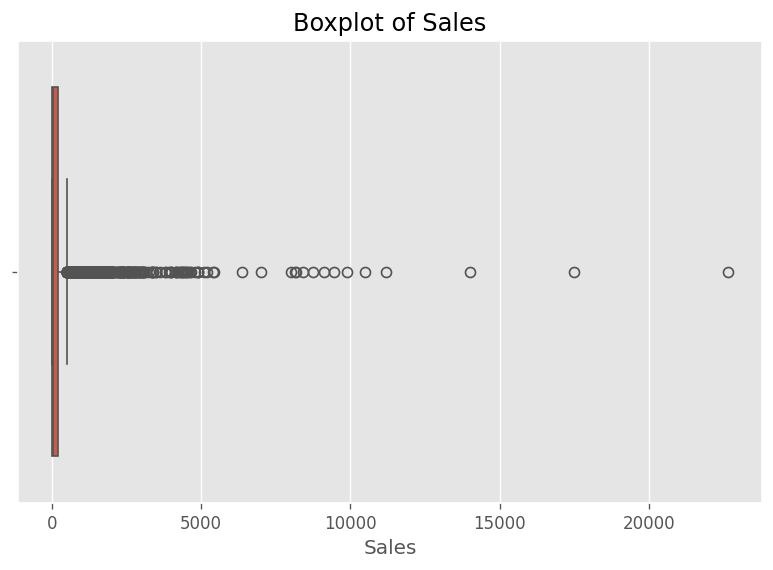

In [52]:
#handling outliars
plt.figure(figsize=(8,5))
sns.boxplot(x=df["Sales"])
plt.title("Boxplot of Sales")
plt.show()

In [53]:
Q1 = df["Sales"].quantile(0.25)
Q3 = df["Sales"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

df = df[(df["Sales"] >= lower_limit) & (df["Sales"] <= upper_limit)]

In [54]:
# shape after removing outliars
df.shape

(8655, 18)

In [55]:
#saving cleaned dataset
df.to_csv("Cleaned_Superstore.csv", index=False)

###
Dashboard and visualization
1. Sales by category

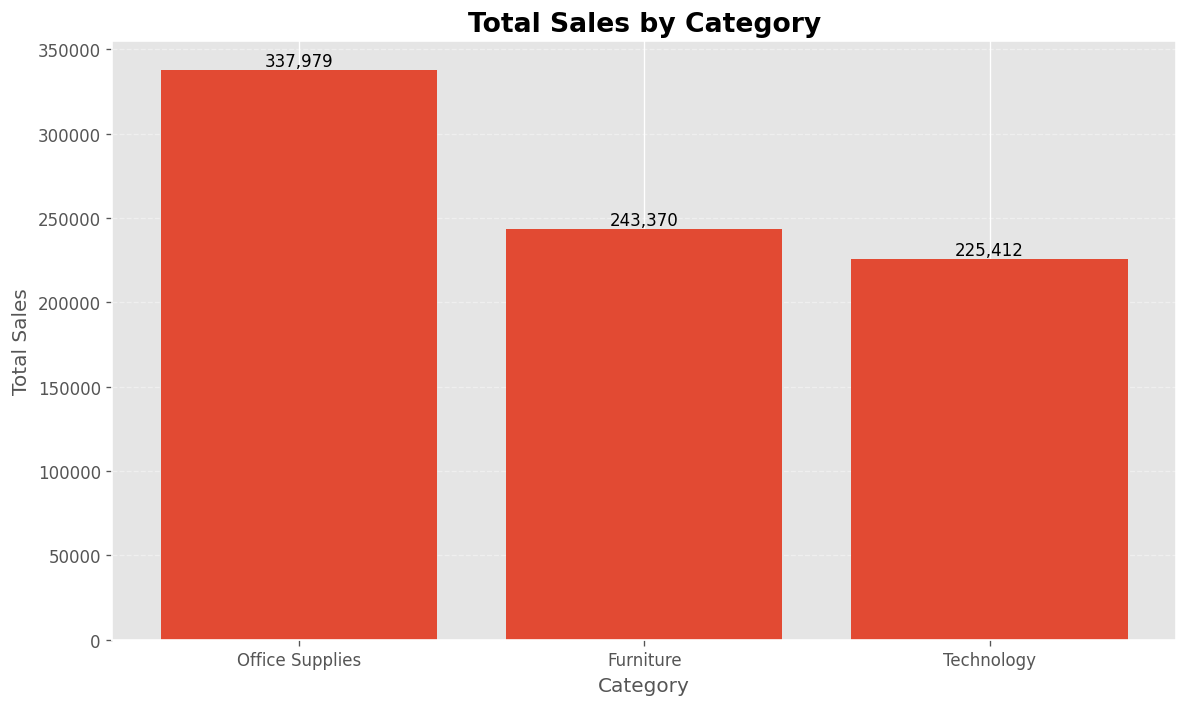

In [56]:
# Calculate total sales by category
sales_by_category = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

# Create figure
plt.figure(figsize=(10,6))

bars = plt.bar(
    sales_by_category.index,
    sales_by_category.values
)

# Title and labels
plt.title("Total Sales by Category", fontsize=16, fontweight="bold")
plt.xlabel("Category", fontsize=12)
plt.ylabel("Total Sales", fontsize=12)

# Add values above bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:,.0f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

# Add horizontal grid
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

### Insight
-By the chart we can conclude that the Office supplies is the catgeory generating the highest sales from the superstore as by the logistics and they need more logistics for their daily activities.
- Office Supplies generated the highest total sales among all product categories.
- Technology recorded the lowest total sales.
- This indicates that Office Supplies contributed the most to overall revenue, while Technology had comparatively lower sales during the analyzed period.


### 2.Sales by region

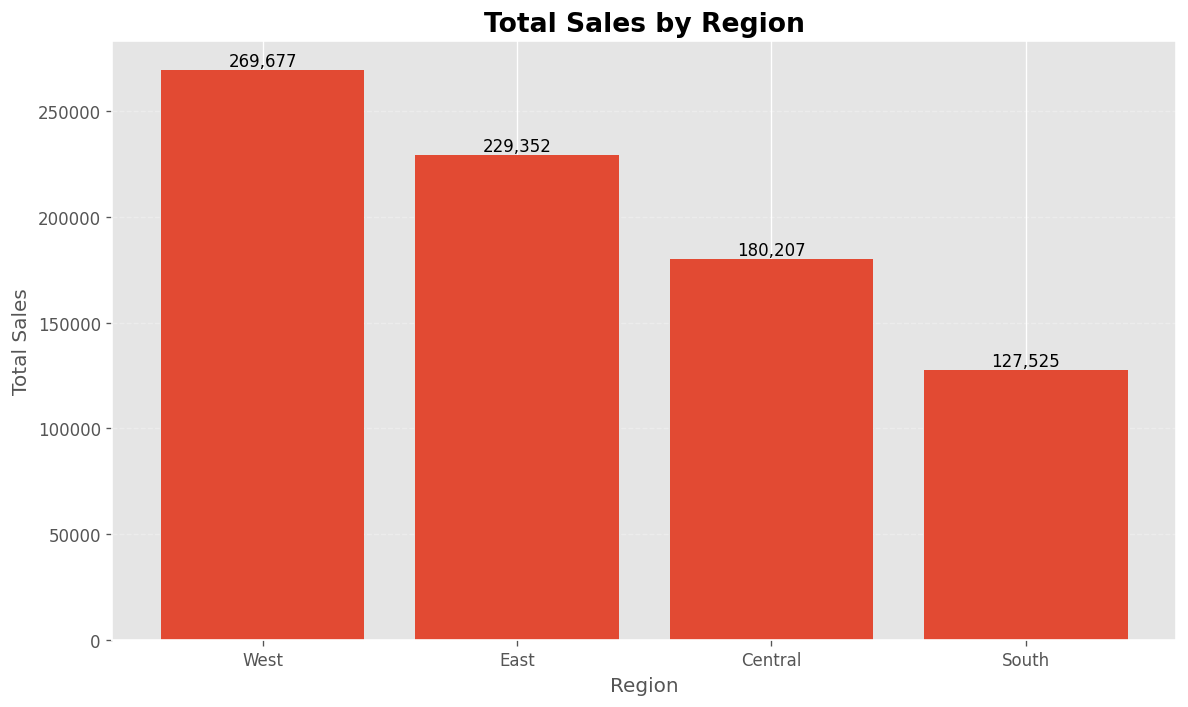

In [57]:
# Calculate total sales by region
plt.style.use('ggplot')
sales_by_region = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))

bars = plt.bar(
    sales_by_region.index,
    sales_by_region.values
)

plt.title("Total Sales by Region", fontsize=16, fontweight="bold")
plt.xlabel("Region")
plt.ylabel("Total Sales")

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:,.0f}",
        ha='center',
        va='bottom'
    )

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()

plt.show()

### Insight

- The West region recorded the highest sales.
- The South region recorded the lowest sales.

### 3. Top 10 states by sales

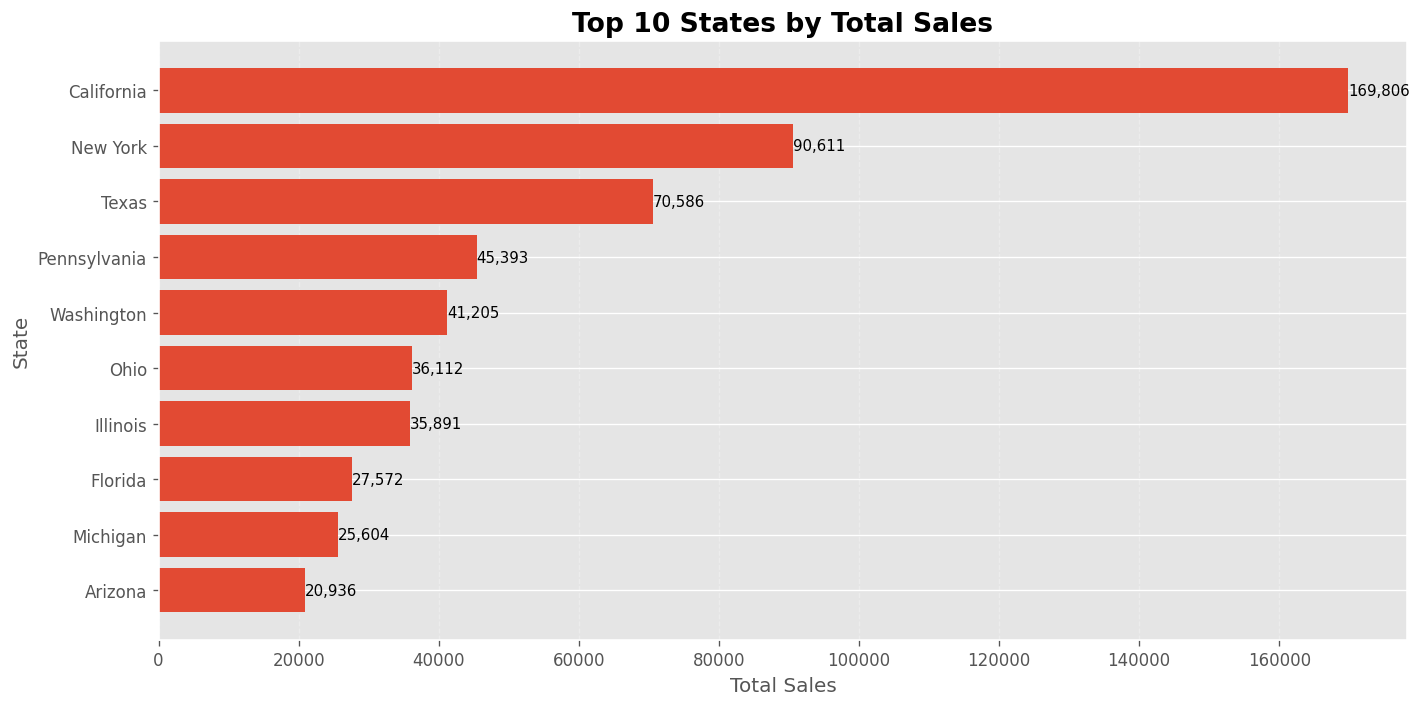

In [58]:
# Calculate top 10 states by sales
top_states = df.groupby("State")["Sales"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))

bars = plt.barh(top_states.index, top_states.values)

plt.title("Top 10 States by Total Sales", fontsize=16, fontweight="bold")
plt.xlabel("Total Sales")
plt.ylabel("State")

# Display values on bars
for bar in bars:
    width = bar.get_width()
    plt.text(
        width,
        bar.get_y() + bar.get_height()/2,
        f"{width:,.0f}",
        va="center",
        fontsize=9
    )

plt.grid(axis="x", linestyle="--", alpha=0.3)

# Highest sales at the top
plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

### Insight
- The chart highlights the top 10 states based on total sales.
- These states contribute the highest share of the company's revenue where California being the maximum sales generating state amongst all.
- Focusing marketing efforts and inventory planning in these high-performing states can help maintain or increase sales.

### 4.Top 10 customers by sales

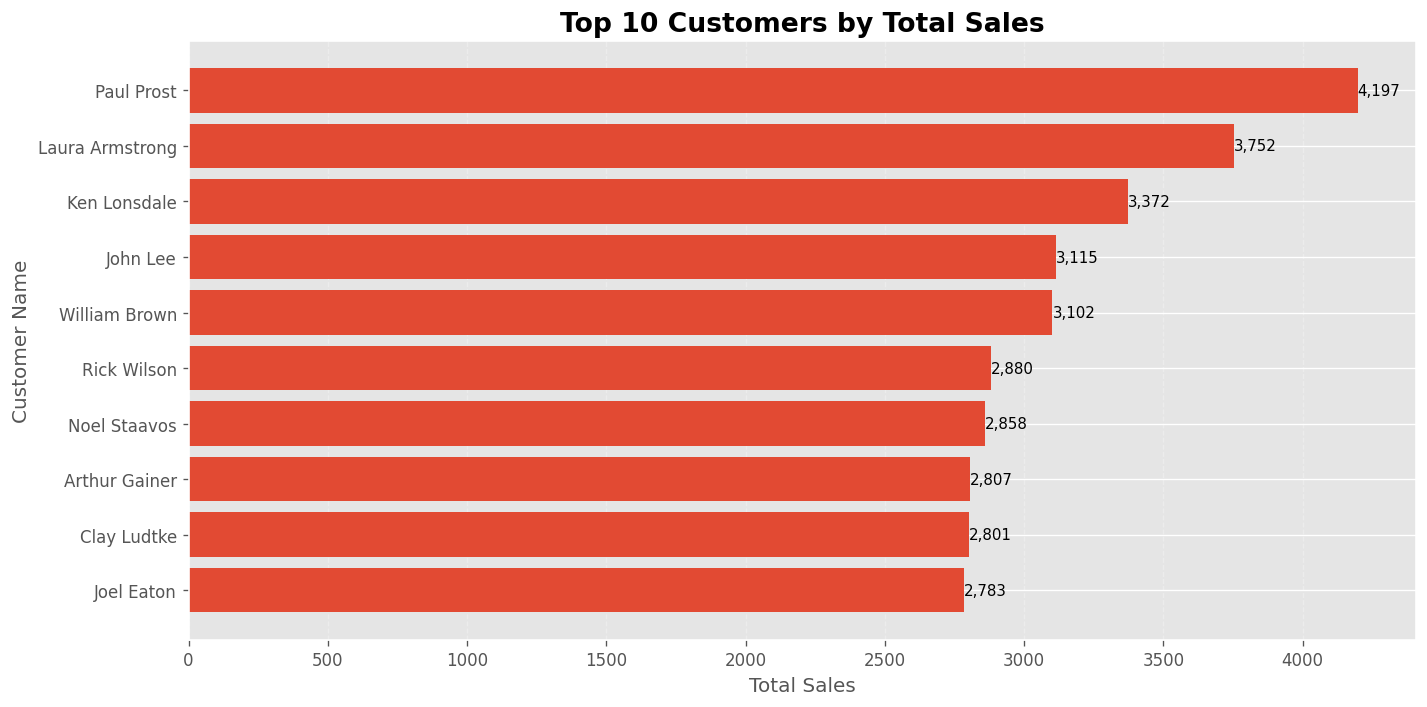

In [59]:
# Calculate top 10 customers by sales
top_customers = (
    df.groupby("Customer Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

bars = plt.barh(top_customers.index, top_customers.values)

plt.title("Top 10 Customers by Total Sales", fontsize=16, fontweight="bold")
plt.xlabel("Total Sales")
plt.ylabel("Customer Name")

# Add value labels
for bar in bars:
    width = bar.get_width()
    plt.text(
        width,
        bar.get_y() + bar.get_height()/2,
        f"{width:,.0f}",
        va="center",
        fontsize=9
    )

plt.grid(axis="x", linestyle="--", alpha=0.3)
plt.style.use("ggplot")
plt.rcParams["figure.dpi"] = 120

# Highest sales at the top
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

### Insight
- The chart identifies the top 10 customers based on total sales.
- These customers contribute significantly to overall revenue.
- Maintaining strong relationships with these customers through loyalty programs and personalized services can help improve customer retention and long-term sales.

## 5. Monthly Sales Trend

C:\Users\KANGANA\AppData\Local\Temp\ipykernel_27152\25538339.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Month"] = df["Order Date"].dt.to_period("M").astype(str)


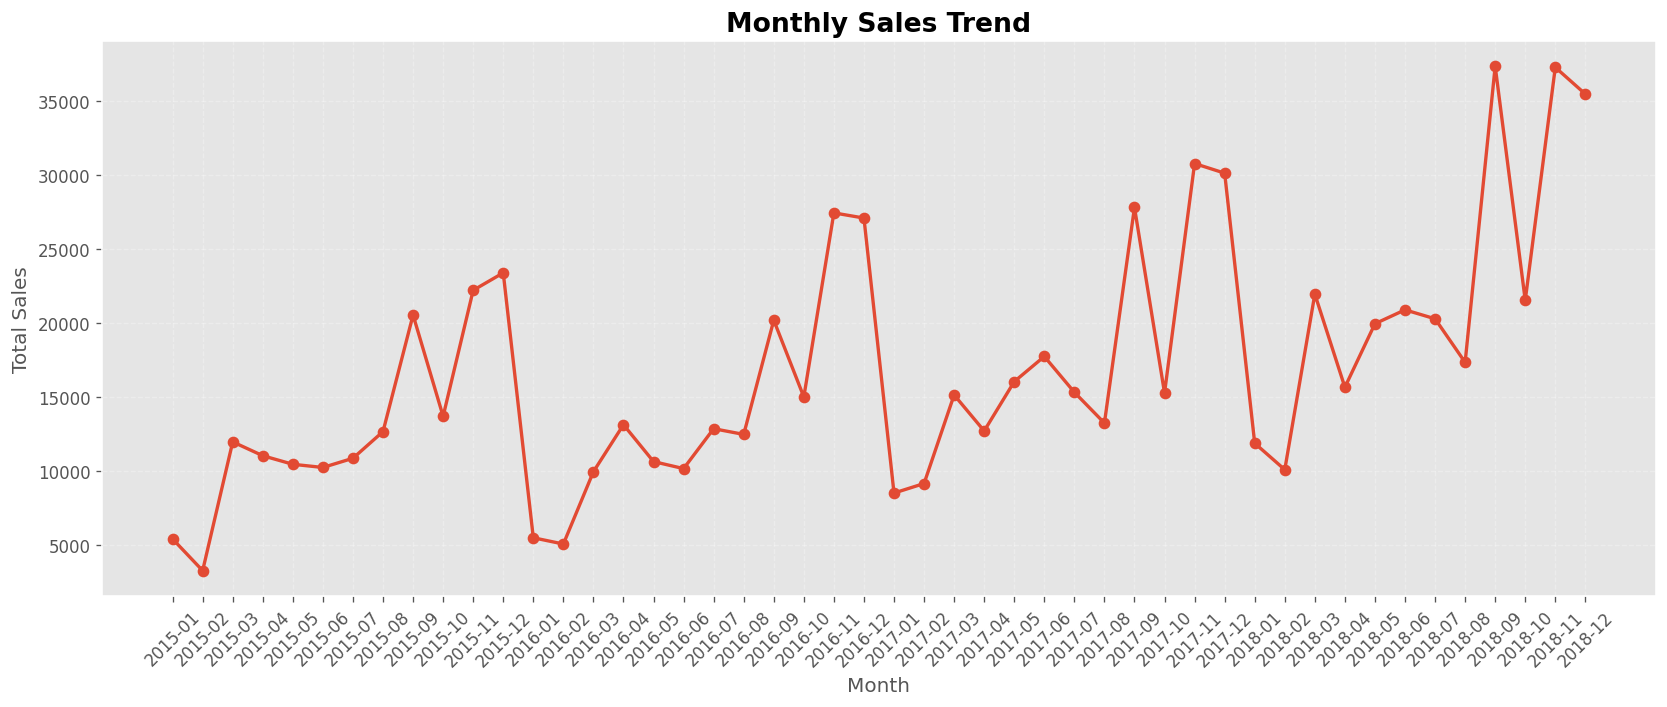

In [60]:
# Create a Month-Year column
df["Month"] = df["Order Date"].dt.to_period("M").astype(str)

# Calculate monthly sales
monthly_sales = df.groupby("Month")["Sales"].sum()

plt.figure(figsize=(14,6))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker="o",
    linewidth=2
)

plt.title("Monthly Sales Trend", fontsize=16, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()

plt.show()

### Insight

- The monthly sales trend shows how sales changed over time.
- Peaks indicate months with higher sales, while dips highlight periods of lower sales.
- Understanding these trends can help the company plan inventory, staffing, and marketing campaigns more effectively.

## 6. Sales Distribution

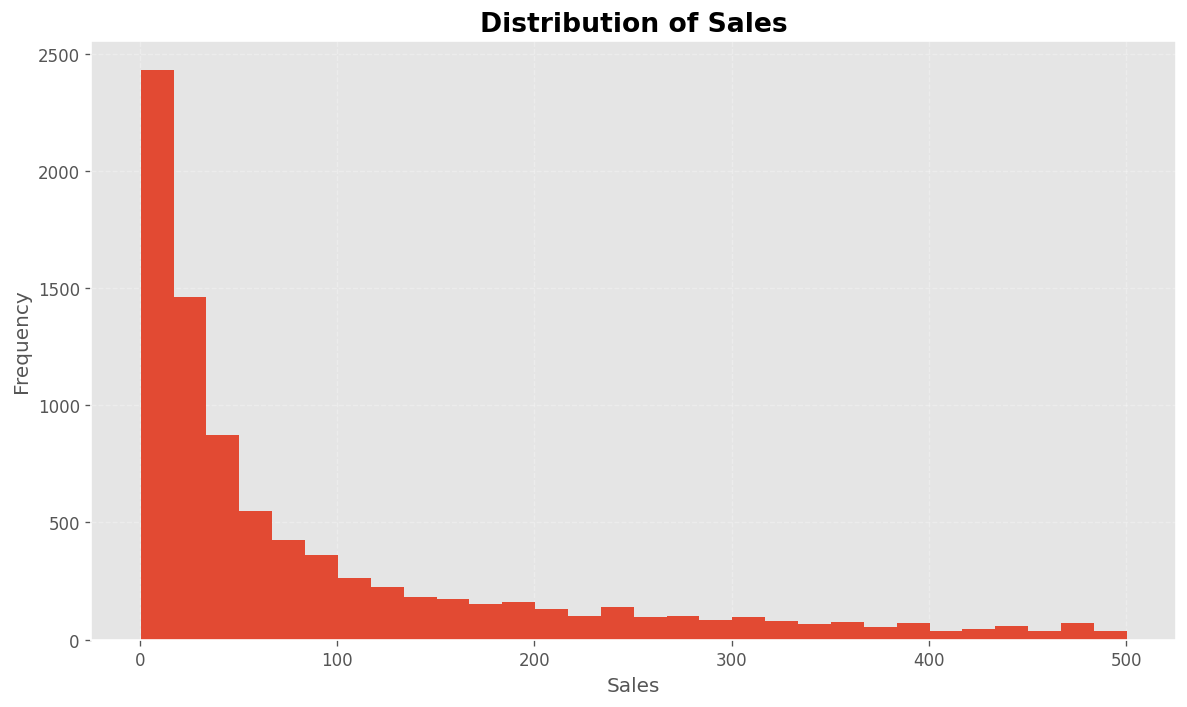

In [61]:
plt.figure(figsize=(10,6))

plt.hist(df["Sales"], bins=30)

plt.title("Distribution of Sales", fontsize=16, fontweight="bold")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()

plt.show()

### Insight
- The histogram shows how sales values are distributed across all transactions.
- Most transactions fall within the lower sales range, while only a few transactions have very high sales values.
- This distribution helps identify common purchasing patterns and the presence of high-value orders.

# Sales Dashboard

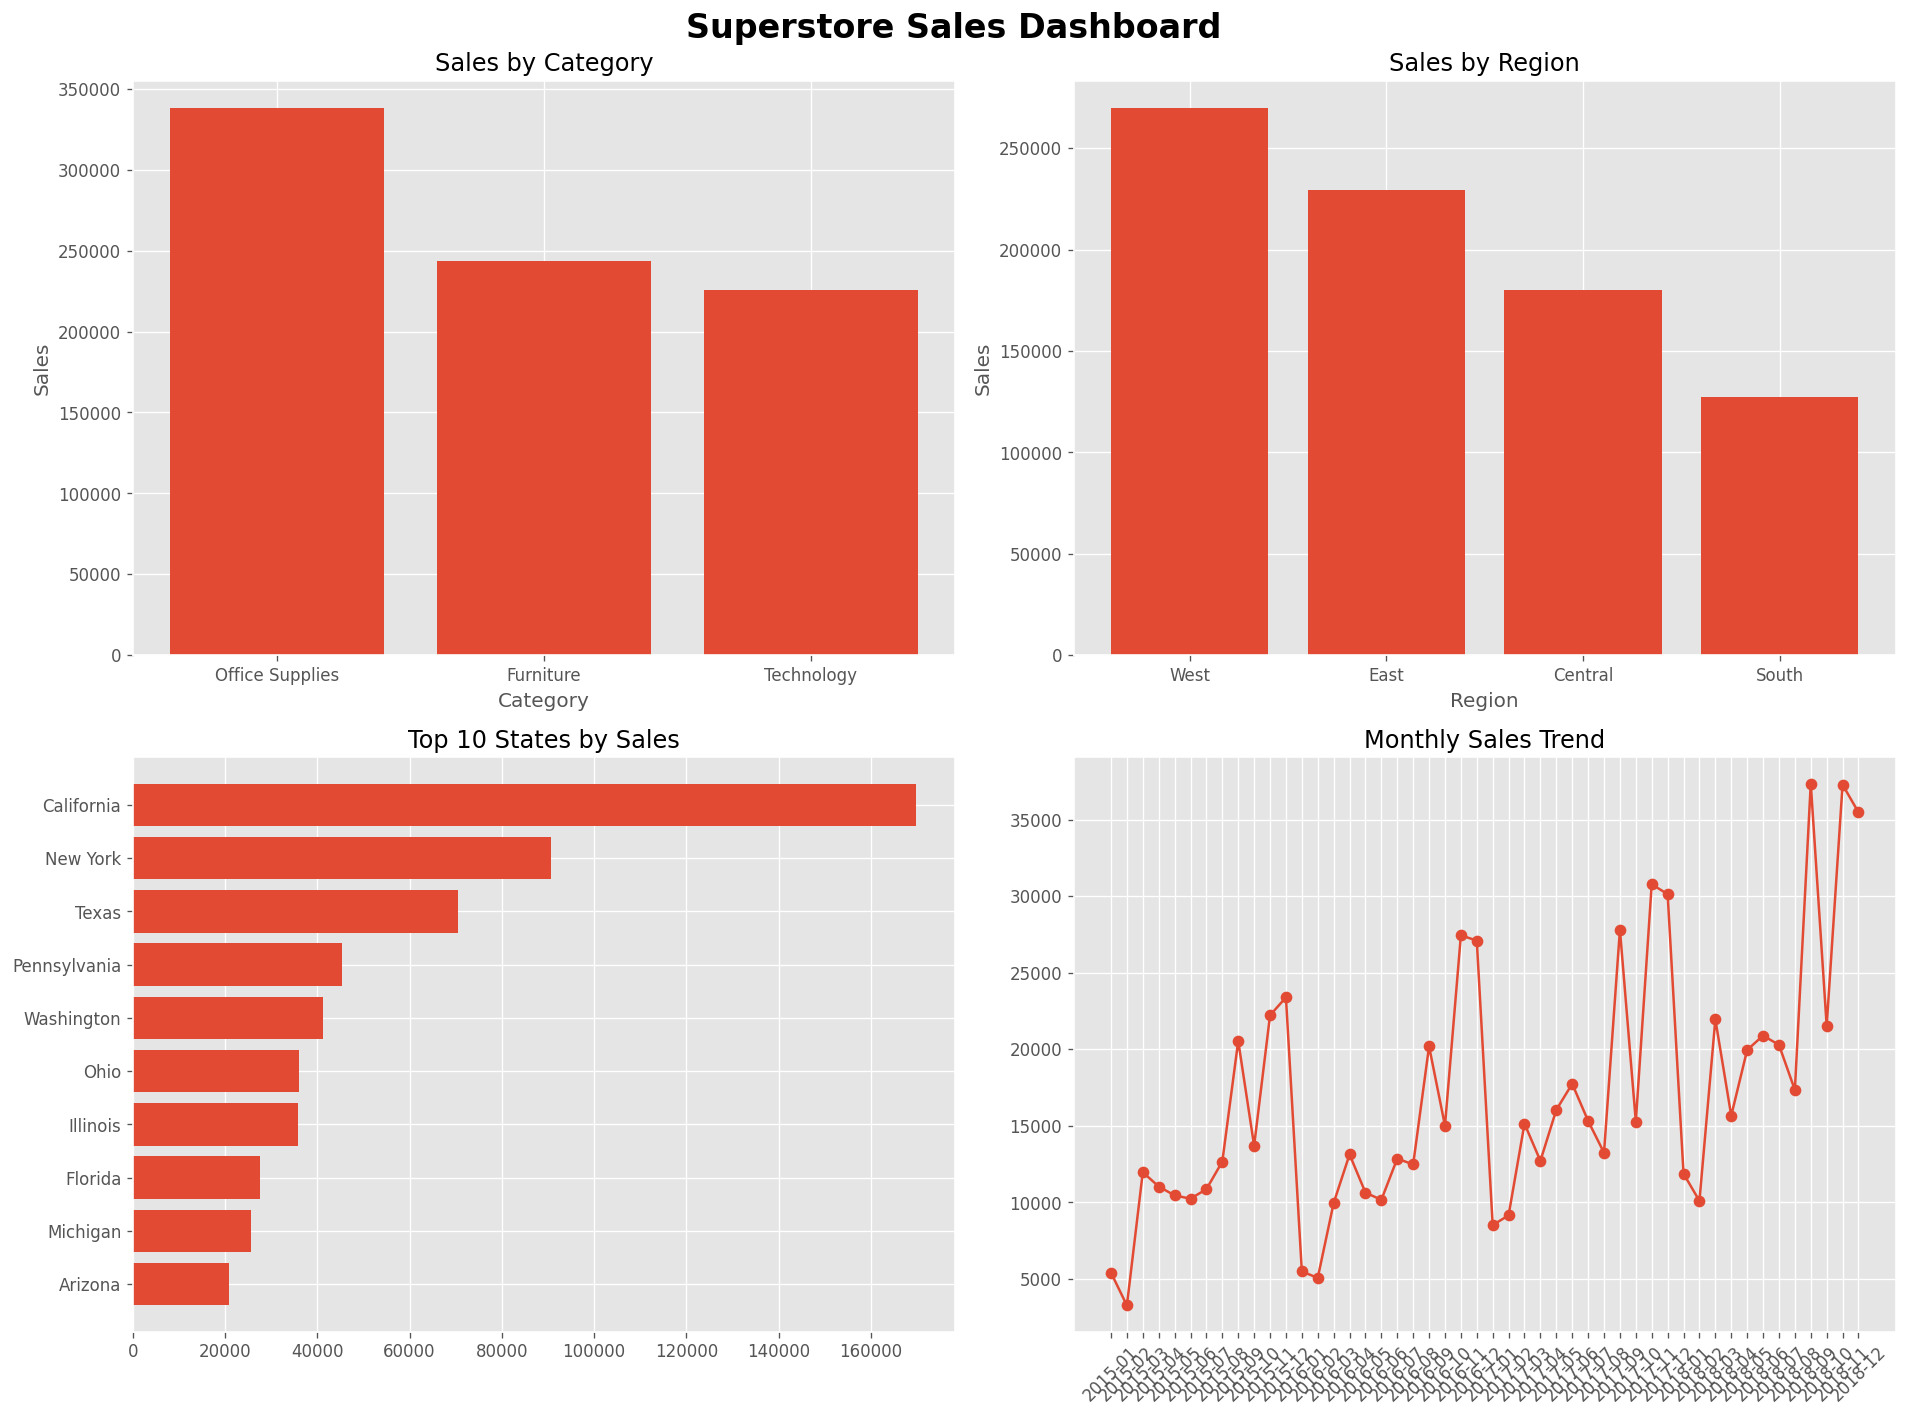

In [62]:
import matplotlib.pyplot as plt

# Prepare the data
sales_by_category = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)
sales_by_region = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)
top_states = df.groupby("State")["Sales"].sum().sort_values(ascending=False).head(10)
monthly_sales = df.groupby("Month")["Sales"].sum()

# Create dashboard
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Sales by Category
axes[0,0].bar(sales_by_category.index, sales_by_category.values)
axes[0,0].set_title("Sales by Category")
axes[0,0].set_xlabel("Category")
axes[0,0].set_ylabel("Sales")

# 2. Sales by Region
axes[0,1].bar(sales_by_region.index, sales_by_region.values)
axes[0,1].set_title("Sales by Region")
axes[0,1].set_xlabel("Region")
axes[0,1].set_ylabel("Sales")

# 3. Top 10 States
axes[1,0].barh(top_states.index, top_states.values)
axes[1,0].set_title("Top 10 States by Sales")
axes[1,0].invert_yaxis()

# 4. Monthly Sales Trend
axes[1,1].plot(monthly_sales.index, monthly_sales.values, marker="o")
axes[1,1].set_title("Monthly Sales Trend")
axes[1,1].tick_params(axis="x", rotation=45)

plt.suptitle(
    "Superstore Sales Dashboard",
    fontsize=20,
    fontweight="bold"
)

plt.tight_layout()

plt.show()